# Homework 10a — Modeling: Linear Regression

## Goal
Fit and evaluate a linear regression model, diagnose the residual assumptions, and decide whether the model is trustworthy for prediction.

This submission uses the **finance-flavored synthetic dataset from the provided Stage 10a starter notebook**. The current project pipeline has a very small model-ready sample after lag/rolling features and the forward target are created, so using the supplied synthetic scaffold provides enough held-out observations for meaningful residual diagnostics.

**Reproducibility:** the random seed is fixed at `7`, the train/test split is chronological (80/20), and every figure is generated by code in this notebook.

**Source note:** Adapted from the course-provided Stage 10a homework starter. Analysis, diagnostics, and interpretations below are written for this submission.


## 1. Imports and reproducibility

The model uses `sklearn.linear_model.LinearRegression`.  
Because the observations are indexed by business date, the split is chronological rather than randomly shuffled.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

SEED = 7
np.random.seed(SEED)

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
print(f"Random seed: {SEED}")


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\yifunger\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Random seed: 7


## 2. Create the finance-flavored synthetic dataset

The starter data contain four observable factors:

- market excess return (`mkt_excess`)
- size factor (`size`)
- value factor (`value`)
- momentum factor (`momentum`)

The response is an asset excess return. The data-generating process also contains a small quadratic momentum effect, `momentum²`, which is deliberately omitted from the baseline model so that specification diagnostics have something meaningful to detect.

The noise variance increases with the absolute market excess return, so the dataset can also reveal a heteroscedasticity concern.


In [2]:
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)

mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = (
    0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
)

noise_scale = 0.0035 + 0.5 * np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)

asset_excess = (
    beta0
    + beta_mkt * mkt_excess
    + beta_size * size
    + beta_value * value
    + beta_mom * momentum
    + beta_mom2 * (momentum ** 2)
    + eps
)

df = pd.DataFrame({
    "date": dates,
    "mkt_excess": mkt_excess,
    "size": size,
    "value": value,
    "momentum": momentum,
    "asset_excess": asset_excess,
})

print("Shape:", df.shape)
df.head()


Shape: (200, 6)


,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


## 3. Train/test split

The first 80% of observations are used for training and the last 20% for testing.

For dated financial observations, a chronological holdout is preferable to random shuffling because it more closely resembles the real forecasting task: train on the past and evaluate on later observations.


In [3]:
feature_cols = ["mkt_excess", "size", "value", "momentum"]
target_col = "asset_excess"

split_idx = int(len(df) * 0.80)

train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

X_train = train[feature_cols]
X_test = test[feature_cols]
y_train = train[target_col]
y_test = test[target_col]

print(f"Training observations: {len(train)}")
print(f"Test observations:     {len(test)}")
print(f"Training period: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test period:     {test['date'].min().date()} to {test['date'].max().date()}")


Training observations: 160
Test observations:     40
Training period: 2024-02-01 to 2024-09-11
Test period:     2024-09-12 to 2024-11-06


## 4. Fit the baseline linear regression

The baseline specification is

\[
y_t = \beta_0 + \beta_1\text{MKT}_t + \beta_2\text{SIZE}_t
+ \beta_3\text{VALUE}_t + \beta_4\text{MOM}_t + \varepsilon_t.
\]

The quadratic momentum term is intentionally left out of the baseline model.


In [4]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
residuals = y_test.to_numpy() - y_pred

baseline_r2 = r2_score(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

coef_table = pd.DataFrame({
    "term": ["intercept"] + feature_cols,
    "coefficient": [baseline_model.intercept_] + list(baseline_model.coef_)
})

print(f"Baseline test R²:   {baseline_r2:.4f}")
print(f"Baseline test RMSE: {baseline_rmse:.6f}")
coef_table


Baseline test R²:   0.3677
Baseline test RMSE: 0.008470


,term,coefficient
0,intercept,-0.000019
1,mkt_excess,0.778493
2,size,0.231084
3,value,-0.209886
4,momentum,0.181456


### Metric interpretation

For this fixed-seed dataset, the baseline model explains about **36.8% of the variance in held-out asset excess returns** (`R² ≈ 0.368`). The test **RMSE is about 0.00847**, or roughly **0.85 percentage points of excess return per observation**.

That is useful signal for a simple benchmark, but it is not strong enough to treat the model as a high-confidence forecasting system. R² measures relative explanatory/predictive fit on this holdout, while RMSE keeps the error in the same units as the target and therefore gives the more operational sense of forecast error magnitude.


## 5. Residual diagnostics

The assumptions are assessed with multiple complementary checks:

1. residuals vs fitted values — linearity / variance pattern
2. residual histogram — distribution shape
3. normal QQ plot — normality
4. residuals vs momentum — predictor-specific misspecification
5. absolute residuals vs absolute market return — heteroscedasticity
6. residual lag-1 plot — independence / serial dependence


In [5]:
# Diagnostic statistics used together with the plots
shapiro_stat, shapiro_p = st.shapiro(residuals)

durbin_watson = np.sum(np.diff(residuals) ** 2) / np.sum(residuals ** 2)

rho_scale, p_scale = st.spearmanr(
    np.abs(residuals),
    np.abs(test["mkt_excess"].to_numpy())
)

r_mom_sq, p_mom_sq = st.pearsonr(
    residuals,
    test["momentum"].to_numpy() ** 2
)

lag1_corr = np.corrcoef(residuals[1:], residuals[:-1])[0, 1]

diagnostic_table = pd.DataFrame({
    "diagnostic": [
        "Shapiro-Wilk normality p-value",
        "Durbin-Watson statistic",
        "Spearman rho: |residual| vs |market return|",
        "p-value: |residual| vs |market return|",
        "Correlation: residual vs momentum²",
        "p-value: residual vs momentum²",
        "Residual lag-1 correlation",
    ],
    "value": [
        shapiro_p,
        durbin_watson,
        rho_scale,
        p_scale,
        r_mom_sq,
        p_mom_sq,
        lag1_corr,
    ],
})

diagnostic_table


,diagnostic,value
0,Shapiro-Wilk normality p-value,0.235451
1,Durbin-Watson statistic,1.295913
2,Spearman rho: |residual| vs |market return|,0.583302
3,p-value: |residual| vs |market return|,0.000078
4,Correlation: residual vs momentum²,0.335170
5,p-value: residual vs momentum²,0.034501
6,Residual lag-1 correlation,0.259985


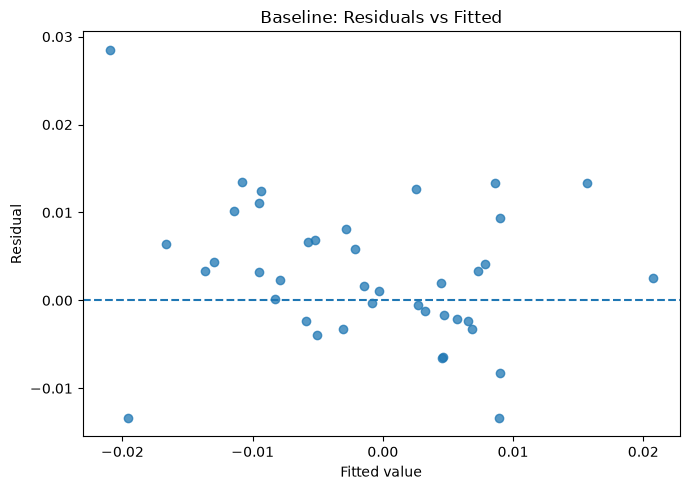

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted value")
plt.ylabel("Residual")
plt.title("Baseline: Residuals vs Fitted")
plt.tight_layout()
plt.show()


### Linearity — interpretation

The residuals are generally centered around zero, but the cloud is not perfectly structureless. In particular, the baseline model omits a known nonlinear `momentum²` component. A separate diagnostic below shows that the test residuals retain a positive association with `momentum²` (`r ≈ 0.335`, `p ≈ 0.035`), which is evidence of mild functional-form misspecification.

**Conclusion:** the linearity/specification assumption is only **partially satisfied** for the baseline model.


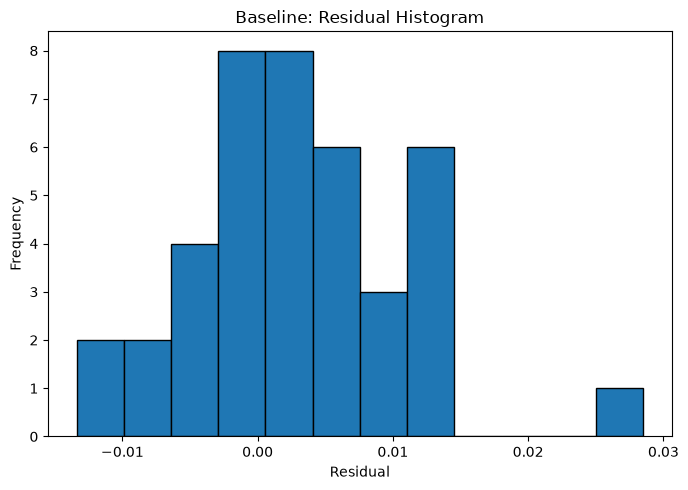

In [7]:
plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=12, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Baseline: Residual Histogram")
plt.tight_layout()
plt.show()


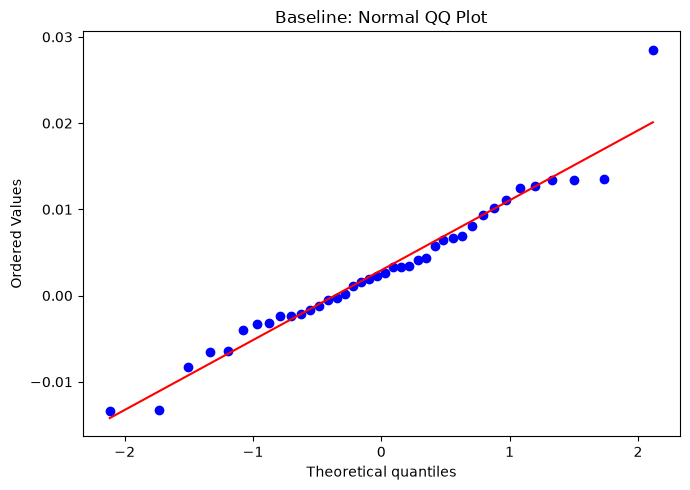

In [8]:
plt.figure(figsize=(7, 5))
st.probplot(residuals, dist="norm", plot=plt)
plt.title("Baseline: Normal QQ Plot")
plt.tight_layout()
plt.show()


### Normality — interpretation

The histogram is roughly mound-shaped, and the QQ plot is reasonably close to the reference line with some tail deviation. The Shapiro-Wilk test gives `p ≈ 0.235`, so at the 5% level there is not strong evidence against normal residuals.

With only 40 held-out residuals, this should not be interpreted as proof of perfect normality; it is better described as **approximately reasonable for this baseline diagnostic**.


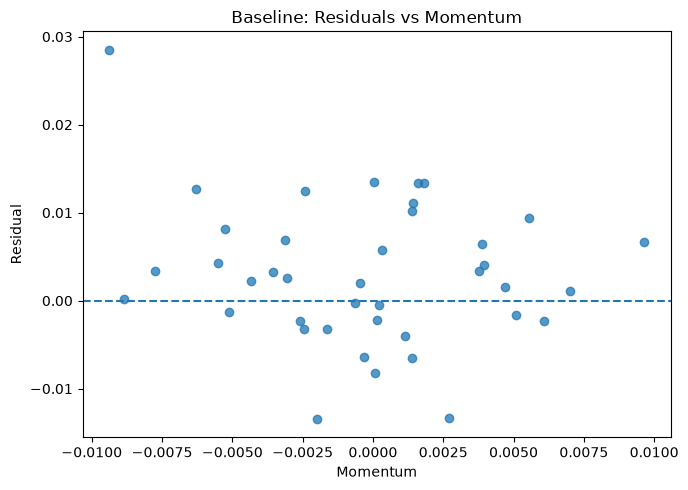

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(test["momentum"], residuals, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Momentum")
plt.ylabel("Residual")
plt.title("Baseline: Residuals vs Momentum")
plt.tight_layout()
plt.show()


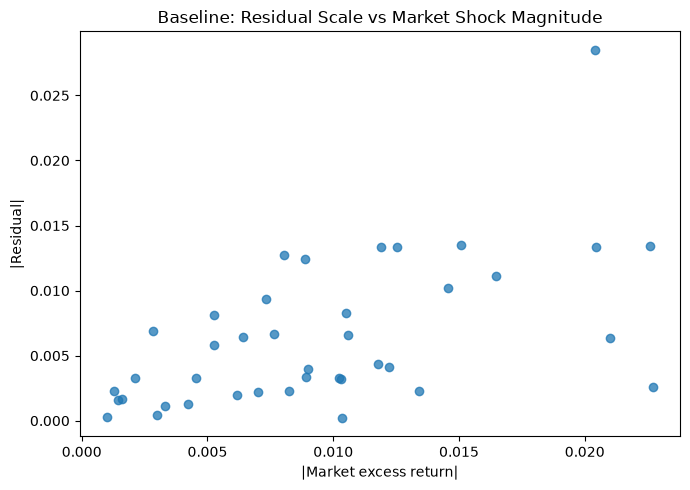

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(np.abs(test["mkt_excess"]), np.abs(residuals), alpha=0.75)
plt.xlabel("|Market excess return|")
plt.ylabel("|Residual|")
plt.title("Baseline: Residual Scale vs Market Shock Magnitude")
plt.tight_layout()
plt.show()


### Homoscedasticity — interpretation

The residual scale becomes larger when the magnitude of the market return is larger. Quantitatively, the Spearman correlation between `|residual|` and `|mkt_excess|` is about **0.583** with a very small p-value (`< 0.001`).

That is strong evidence that the conditional error variance is not constant.

**Conclusion:** the homoscedasticity assumption is **not well satisfied**. In a real modeling workflow, I would consider heteroscedasticity-robust inference, weighted least squares, or an explicit volatility model rather than treating constant variance as credible.


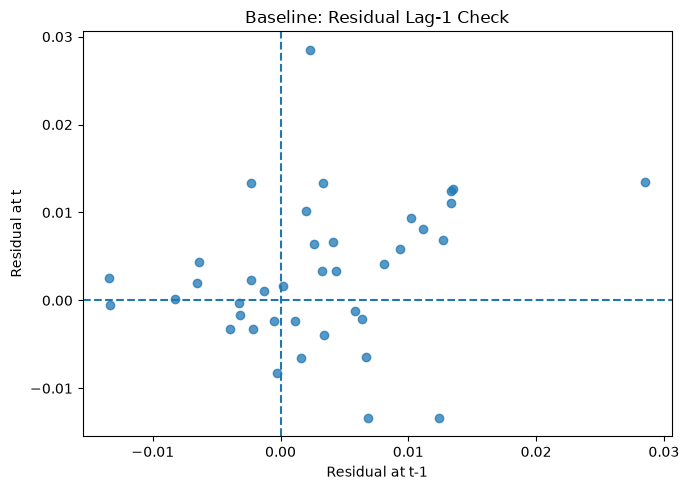

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(residuals[:-1], residuals[1:], alpha=0.75)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Residual at t-1")
plt.ylabel("Residual at t")
plt.title("Baseline: Residual Lag-1 Check")
plt.tight_layout()
plt.show()


### Independence — interpretation

The lag-1 residual correlation is about **0.260**, and the Durbin-Watson statistic is about **1.30**. A Durbin-Watson value near 2 would be more consistent with no first-order serial correlation, so these diagnostics suggest some positive dependence in this particular held-out sample.

Because the data are synthetic and the true shocks were generated independently, part of this pattern can arise from sampling variability and model misspecification. Still, diagnostics should be interpreted from the observed sample rather than assumed away.

**Conclusion:** independence is **not fully convincing** in the baseline residuals.


## 6. Explanation vs prediction

These are different goals.

- **Prediction:** asks whether the model produces accurate held-out forecasts. R² and RMSE are directly relevant.
- **Explanation:** asks how predictors are associated with the response and whether coefficient interpretation is reliable.

Even a model with good predictive performance does **not** establish causality. In real financial data, omitted variables, simultaneity, changing regimes, measurement choices, and correlated factors can all make coefficients poor causal explanations. Conversely, a coefficient can be substantively interesting even when overall predictive performance is only moderate.

Therefore I treat the coefficients here as **conditional associations in a model**, not causal effects.


## 7. Stretch: add a transformed feature

The residual diagnostics suggest a missing nonlinear momentum component, so I add

\[
\text{momentum\_sq} = \text{momentum}^2.
\]

The transformed specification is still a **linear regression** because it remains linear in the unknown coefficients:

\[
y = \beta_0 + \beta_1x_1 + \cdots + \beta_4x_4 + \beta_5x_4^2 + \varepsilon.
\]

The predictor can be nonlinear in the original variable while the model is linear in the parameters \(\beta\).


In [12]:
df["momentum_sq"] = df["momentum"] ** 2

feature_cols_2 = feature_cols + ["momentum_sq"]

train2 = df.iloc[:split_idx].copy()
test2 = df.iloc[split_idx:].copy()

X2_train = train2[feature_cols_2]
X2_test = test2[feature_cols_2]

transformed_model = LinearRegression()
transformed_model.fit(X2_train, y_train)

y_pred2 = transformed_model.predict(X2_test)
residuals2 = y_test.to_numpy() - y_pred2

transformed_r2 = r2_score(y_test, y_pred2)
transformed_rmse = np.sqrt(mean_squared_error(y_test, y_pred2))

r_mom_sq_2, p_mom_sq_2 = st.pearsonr(
    residuals2,
    test2["momentum_sq"].to_numpy()
)

comparison = pd.DataFrame({
    "model": ["Baseline", "Baseline + momentum²"],
    "test_R2": [baseline_r2, transformed_r2],
    "test_RMSE": [baseline_rmse, transformed_rmse],
    "corr(residual, momentum²)": [r_mom_sq, r_mom_sq_2],
    "p_value_corr": [p_mom_sq, p_mom_sq_2],
})

comparison


,model,test_R2,test_RMSE,"corr(residual, momentum²)",p_value_corr
0,Baseline,0.367706,0.008470,0.335170,0.034501
1,Baseline + momentum²,0.368093,0.008467,0.278085,0.082308


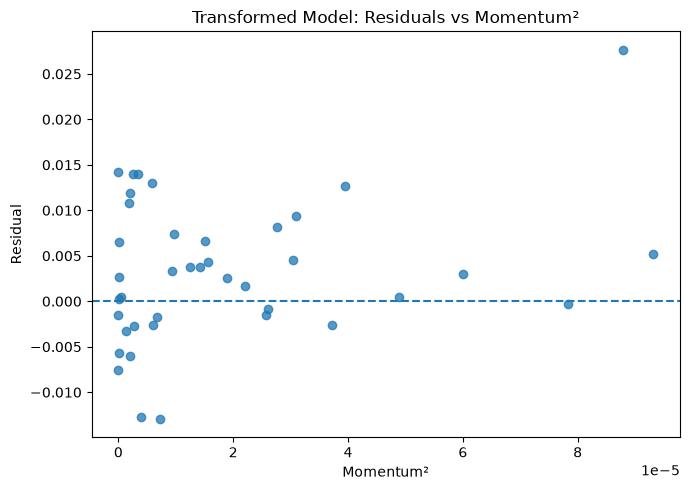

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(test2["momentum_sq"], residuals2, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Momentum²")
plt.ylabel("Residual")
plt.title("Transformed Model: Residuals vs Momentum²")
plt.tight_layout()
plt.show()


### Stretch comparison

Adding `momentum²` produces a **small** improvement in held-out metrics: R² rises from about **0.3677 to 0.3681** and RMSE falls from about **0.008470 to 0.008467**.

The more important specification result is that the residual association with `momentum²` weakens: the correlation falls from about **0.335 (p ≈ 0.035)** to **0.278 (p ≈ 0.082)**. This moves the residual pattern in the expected direction, although the improvement is modest because the quadratic effect in the starter data is intentionally small relative to the noise.

This is a good example of why a transformed term should be justified by diagnostics rather than added only to chase a larger R².


## 8. Final conclusion — do I trust the model?

I would trust the baseline linear regression as a **useful benchmark**, but **not as a fully reliable forecasting model**.

The positive case is that it captures real held-out signal: test R² is about **0.368** and RMSE is about **0.00847**. Residual normality is also reasonably acceptable in this sample.

However, the diagnostics reveal important limitations. Residual variance increases with market-shock magnitude, so homoscedasticity is violated. The baseline residuals also retain evidence of a missing quadratic momentum relationship, and the lag-1 diagnostics do not make independence fully convincing. The transformed model improves specification slightly, but not enough to solve the broader variance and dependence concerns.

**Next steps:** with real project data, I would (1) expand the historical sample, (2) preserve chronological train/test splitting, (3) compare against a naive benchmark, (4) consider robust or weighted regression for heteroscedasticity, and (5) evaluate alternative volatility-focused models if residual dependence persists.

Overall, the model is **useful for learning and benchmarking, but not trustworthy enough for high-stakes financial decisions without further validation and model refinement**.


## 9. Rubric checklist

- ✅ 80/20 train/test split
- ✅ `sklearn.linear_model.LinearRegression`
- ✅ predictions and residuals
- ✅ test R² and RMSE
- ✅ residuals vs fitted
- ✅ residual histogram
- ✅ normal QQ plot
- ✅ residuals vs key predictor
- ✅ heteroscedasticity-specific check
- ✅ residual lag-1 / independence check
- ✅ written interpretation of linearity
- ✅ written interpretation of homoscedasticity
- ✅ written interpretation of normality
- ✅ written interpretation of independence
- ✅ explanation vs prediction distinction
- ✅ clear trust/usefulness conclusion
- ✅ fixed random seed and reproducible workflow
- ✅ optional transformed feature with comparison
